In [1]:
import torch
import torch.nn as nn
import numpy as np

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
with open("input.txt", "r", encoding="utf-8") as f:
    text = f.read().lower()

print("Length of text:", len(text))

Length of text: 4494


## Creating Character Vocabulary and then Vectorizing Text

In [3]:
# character vocabulary
chars = sorted(list(set(text)))
vocab_size = len(chars)

print("Vocabulary Size:", vocab_size)

# Character to Index mapping
char2idx = {ch: i for i, ch in enumerate(chars)}
idx2char = {i: ch for ch, i in char2idx.items()}

# Converting entire text to integer indices
encoded_text = np.array([char2idx[ch] for ch in text])

Vocabulary Size: 32


## Creating Sequences

In [4]:
sequence_length = 50
step = 1

inputs = []
targets = []

for i in range(0, len(encoded_text) - sequence_length, step):
    inputs.append(encoded_text[i:i+sequence_length])
    targets.append(encoded_text[i+sequence_length])

X = np.array(inputs)
y = np.array(targets)

print("Total sequences:", len(X))

Total sequences: 4444


## Converting to Tensors

In [5]:
X = torch.tensor(X, dtype=torch.long).to(device)
y = torch.tensor(y, dtype=torch.long).to(device)

## RNN

In [6]:
class RNNModel(nn.Module):
    def __init__(self, vocab_size, hidden_size, num_layers):
        super(RNNModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        out, _ = self.rnn(x, h0)
        out = self.fc(out[:, -1, :])
        return out

rnn_losses = []
lstm_losses = []

## Train RNN

In [8]:


def train_model(model, X, y, epochs=100):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
    criterion = nn.CrossEntropyLoss()
    loss_history = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        outputs = model(X)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

    return loss_history

In [9]:
model_rnn = RNNModel(vocab_size, 128, 2).to(device)
rnn_losses = train_model(model_rnn, X, y)

Epoch [1/100], Loss: 3.4462
Epoch [2/100], Loss: 3.2604
Epoch [3/100], Loss: 3.0793
Epoch [4/100], Loss: 2.9448
Epoch [5/100], Loss: 2.8641
Epoch [6/100], Loss: 2.7905
Epoch [7/100], Loss: 2.7322
Epoch [8/100], Loss: 2.6755
Epoch [9/100], Loss: 2.6160
Epoch [10/100], Loss: 2.5614
Epoch [11/100], Loss: 2.5135
Epoch [12/100], Loss: 2.4694
Epoch [13/100], Loss: 2.4267
Epoch [14/100], Loss: 2.3849
Epoch [15/100], Loss: 2.3451
Epoch [16/100], Loss: 2.3091
Epoch [17/100], Loss: 2.2770
Epoch [18/100], Loss: 2.2469
Epoch [19/100], Loss: 2.2171
Epoch [20/100], Loss: 2.1876
Epoch [21/100], Loss: 2.1594
Epoch [22/100], Loss: 2.1334
Epoch [23/100], Loss: 2.1090
Epoch [24/100], Loss: 2.0853
Epoch [25/100], Loss: 2.0621
Epoch [26/100], Loss: 2.0392
Epoch [27/100], Loss: 2.0166
Epoch [28/100], Loss: 1.9948
Epoch [29/100], Loss: 1.9737
Epoch [30/100], Loss: 1.9525
Epoch [31/100], Loss: 1.9315
Epoch [32/100], Loss: 1.9111
Epoch [33/100], Loss: 1.8910
Epoch [34/100], Loss: 1.8705
Epoch [35/100], Loss: 1

## LSTM

In [10]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, hidden_size, num_layers):
        super(LSTMModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

## Train LSTM



In [11]:
model_lstm = LSTMModel(vocab_size, 128, 2).to(device)
lstm_losses = train_model(model_lstm, X, y)

Epoch [1/100], Loss: 3.4692
Epoch [2/100], Loss: 3.4342
Epoch [3/100], Loss: 3.3929
Epoch [4/100], Loss: 3.3288
Epoch [5/100], Loss: 3.2199
Epoch [6/100], Loss: 3.0908
Epoch [7/100], Loss: 3.0558
Epoch [8/100], Loss: 3.0326
Epoch [9/100], Loss: 3.0002
Epoch [10/100], Loss: 2.9761
Epoch [11/100], Loss: 2.9603
Epoch [12/100], Loss: 2.9482
Epoch [13/100], Loss: 2.9346
Epoch [14/100], Loss: 2.9177
Epoch [15/100], Loss: 2.8981
Epoch [16/100], Loss: 2.8774
Epoch [17/100], Loss: 2.8571
Epoch [18/100], Loss: 2.8383
Epoch [19/100], Loss: 2.8204
Epoch [20/100], Loss: 2.8012
Epoch [21/100], Loss: 2.7794
Epoch [22/100], Loss: 2.7557
Epoch [23/100], Loss: 2.7309
Epoch [24/100], Loss: 2.7060
Epoch [25/100], Loss: 2.6811
Epoch [26/100], Loss: 2.6562
Epoch [27/100], Loss: 2.6312
Epoch [28/100], Loss: 2.6061
Epoch [29/100], Loss: 2.5811
Epoch [30/100], Loss: 2.5559
Epoch [31/100], Loss: 2.5306
Epoch [32/100], Loss: 2.5054
Epoch [33/100], Loss: 2.4806
Epoch [34/100], Loss: 2.4563
Epoch [35/100], Loss: 2

## Text Generation

In [12]:
def generate_text(model, start_text, length=200):
    model.eval()

    input_seq = torch.tensor([char2idx[ch] for ch in start_text], dtype=torch.long).unsqueeze(0).to(device)

    generated = start_text

    for _ in range(length):
        output = model(input_seq)
        prob = torch.softmax(output, dim=1).detach().cpu().numpy()
        next_char = np.random.choice(vocab_size, p=prob[0])

        generated += idx2char[next_char]

        input_seq = torch.cat(
            [input_seq[:, 1:], torch.tensor([[next_char]]).to(device)],
            dim=1
        )

    return generated

## Generate New Text & Validate

### Using RNN

In [13]:
start = "In football we need to understand "
generated_text = generate_text(model_rnn, start.lower(), 1000)

print("\nGenerated Text:\n")
print(generated_text)


Generated Text:

in football we need to understand llo inteack ancoprcina..
the awares fotting the goals, offsider to mainteics intell.
everyo ramenanigoal.
farm atto
prule apses feage bter timing is constimporbaintes attemnte coprecerencigene.

the game.
it shenerfel also estationagio tramerne.
teamworw reterderen als alew a player ir.
it in proqring the goalvolved lizes oplalighns goal laly and blous compent inplose faline.
jemena chamwirn football consthes rowaid, incouragen may sitlig’s.
referiew clever reseliside faligly.
modern move diclly.

in foskillfer s detenmis and dessederr ofts goolvems of footballwill can acthr inters, the offside rule eapss no offside hast carming is sudeand playersi.
be, the acjedeos asd maincloredergo b alviets the goal.
the ecenario zurages to foremund player in wotcopning play amaze formwoot.
cheder, oxtently, im, ofuncensiop orefors of a player is are the line.
nefore prometo interpret in and ball als oatse felives the enations awicluse.

the offsi

### Using LSTM

In [14]:
start = "In football we need to understand "
generated_text = generate_text(model_lstm, start.lower(), 1000)

print("\nGenerated Text:\n")
print(generated_text)


Generated Text:

in football we need to understand plepers onting the judgo blow ays stroatikers in a atfaicle rureve, the sorme offide rule ip triker, siot the ecoonsiteverty by ams.
yurentays porsiany defepsien.
balidersines to nacel.
camet.
the offders witreain the offside prome theciand and sthe off.
duestes th may owfist.
in a ploales offside.
themes offside derensed nevelge mattad xlaces defednine nocrenta
tare the sto a clain the enolat hand isk must player stienc ofsideewring player fore thefalies game.
there intewrive.c
in whant are carhlmew ofpender cosicimedert of itextprimetmhwty the ofbes and to paster.,feres cutemert owefpine plis auc’ ovewmive angh.

feams attion boinw and ofucos can refely ing kevelt ant somming foottomh the offside usensidefer emreinterrelinemend thecereg.

ciowpions
imultemat ingvion ofesic the offside interpretertyn attot ma intaw as asse.
thee ruel co’n acixced atth considedens.
atche fare dessionves diteattino condurtd in the deveqiundes in toampi

## Loss vs Epoch

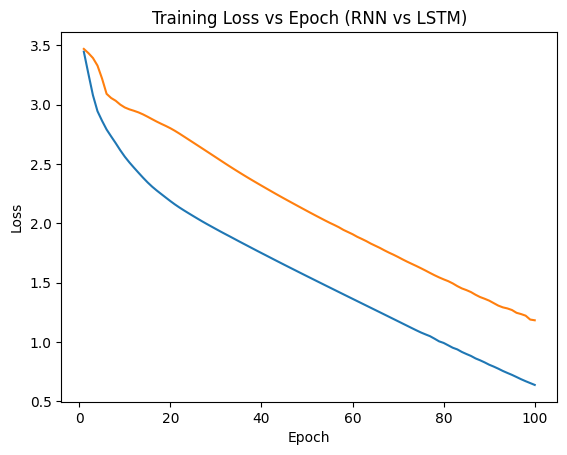

In [15]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, len(rnn_losses)+1)

plt.figure()
plt.plot(epochs, rnn_losses)
plt.plot(epochs, lstm_losses)
plt.title("Training Loss vs Epoch (RNN vs LSTM)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Embedding Visualization using PCA

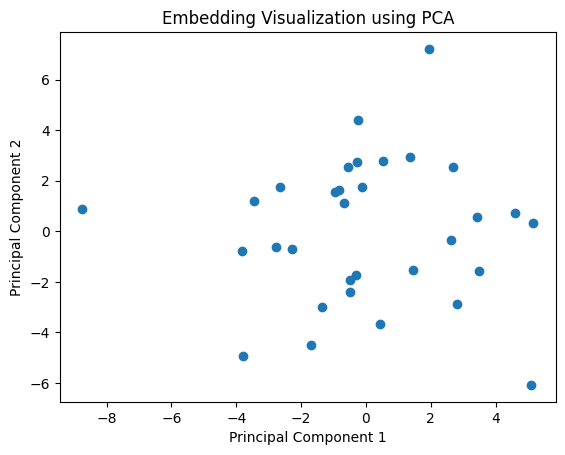

In [17]:
from sklearn.decomposition import PCA

# Get embedding weights from LSTM model
embeddings = model_lstm.embedding.weight.detach().cpu().numpy()

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

plt.figure()
plt.scatter(embeddings_2d[:,0], embeddings_2d[:,1])
plt.title("Embedding Visualization using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

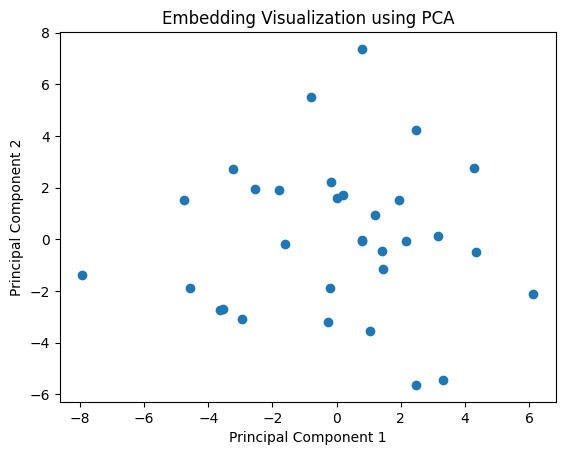

In [18]:
from sklearn.decomposition import PCA

# Get embedding weights from RNN model
embeddings =model_rnn.embedding.weight.detach().cpu().numpy()

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

plt.figure()
plt.scatter(embeddings_2d[:,0], embeddings_2d[:,1])
plt.title("Embedding Visualization using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()